# Predictive Modelling with Embeddings

**Predictive Model: Urban vs Rural Classification for Birmingham LSOAs**

**Using Google Satellite Embeddings and Rural/Urban Classification data**

## Step 1: Import Libraries

In [19]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import box
from matplotlib.patches import Patch
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.colors as colors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## Step 2: Load Data

In [20]:
print("="*60)
print("STEP 2: Loading Data")
print("="*60)

# Load the LSOA GeoPackage with satellite band data
print("\nLoading LSOA satellite data...")
lsoa_gdf = gpd.read_file('extracted-lsoa-geopackage_2021_output.gpkg')
print(f"✓ Loaded {len(lsoa_gdf)} LSOAs")
print(f"✓ Columns: {lsoa_gdf.columns.tolist()[:10]}...")
print(f"✓ CRS: {lsoa_gdf.crs}")

# Load Rural Urban Classification
print("\nLoading Rural Urban Classification...")
ruc_gdf = gpd.read_file('Rural_Urban_Classification_(2021)_of_LSOAs_in_EW.geojson')
print(f"✓ Loaded {len(ruc_gdf)} LSOAs")
print(f"✓ Columns: {ruc_gdf.columns.tolist()}")
print(f"✓ CRS: {ruc_gdf.crs}")

# Display RUC classification values
print("\nRUC21CD unique values and meanings:")
ruc_mapping = {
    'UN1': 'Urban Major Conurbation',
    'UF1': 'Urban Minor Conurbation',
    'RLN1': 'Rural Town and Fringe in a Sparse Setting',
    'RSN1': 'Rural Village and Dispersed in a Sparse Setting',
    'RSF1': 'Rural Village and Dispersed',
    'RLF1': 'Rural Town and Fringe'
}
for code, meaning in ruc_mapping.items():
    count = (ruc_gdf['RUC21CD'] == code).sum()
    if count > 0:
        print(f"  {code}: {meaning} ({count} LSOAs)")

STEP 2: Loading Data

Loading LSOA satellite data...
✓ Loaded 46844 LSOAs
✓ Columns: ['data_zone_code', 'band1_mean', 'band2_mean', 'band3_mean', 'band4_mean', 'band5_mean', 'band6_mean', 'band7_mean', 'band8_mean', 'band9_mean']...
✓ CRS: EPSG:27700

Loading Rural Urban Classification...
✓ Loaded 35672 LSOAs
✓ Columns: ['LSOA21CD', 'LSOA21NM', 'LSOA21NMW', 'RUC21CD', 'RUC21NM', 'Urban_rural_flag', 'ObjectId', 'geometry']
✓ CRS: EPSG:4326

RUC21CD unique values and meanings:
  UN1: Urban Major Conurbation (27106 LSOAs)
  UF1: Urban Minor Conurbation (2451 LSOAs)
  RLN1: Rural Town and Fringe in a Sparse Setting (2127 LSOAs)
  RSN1: Rural Village and Dispersed in a Sparse Setting (1735 LSOAs)
  RSF1: Rural Village and Dispersed (1232 LSOAs)
  RLF1: Rural Town and Fringe (1021 LSOAs)


## Step 3: Prepare Data for Merging

In [21]:
print("\n" + "="*60)
print("STEP 3: Preparing Data for Merging")
print("="*60)

# Check the format of data_zone_code
print(f"Sample data_zone_code values: {lsoa_gdf['data_zone_code'].head(10).tolist()}")
print(f"Sample LSOA21CD values: {ruc_gdf['LSOA21CD'].head(10).tolist()}")

# Create a mapping: data_zone_code is actually the LSOA code
# Rename for clarity
lsoa_gdf = lsoa_gdf.rename(columns={'data_zone_code': 'LSOA21CD'})

# Ensure both are string type
lsoa_gdf['LSOA21CD'] = lsoa_gdf['LSOA21CD'].astype(str)
ruc_gdf['LSOA21CD'] = ruc_gdf['LSOA21CD'].astype(str)

print(f"\n✓ Renamed column to LSOA21CD for consistency")


STEP 3: Preparing Data for Merging
Sample data_zone_code values: ['E01000001', 'E01000002', 'E01000003', 'E01000005', 'E01000006', 'E01000007', 'E01000008', 'E01000009', 'E01000011', 'E01000012']
Sample LSOA21CD values: ['E01000001', 'E01000002', 'E01000003', 'E01000005', 'E01000006', 'E01000007', 'E01000008', 'E01000009', 'E01000011', 'E01000012']

✓ Renamed column to LSOA21CD for consistency


## Step 4: Filter for Birmingham LSOAs

In [22]:
print("\n" + "="*60)
print("STEP 4: Filtering Birmingham LSOAs")
print("="*60)

# Create mask for Birmingham LSOAs using LSOA codes
# Birmingham LSOAs start with 'E010'
birmingham_mask = lsoa_gdf['LSOA21CD'].str.startswith('E010', na=False)
print(f"✓ LSOA code filter: {birmingham_mask.sum()} LSOAs start with E010")

# Apply filter
lsoa_birmingham = lsoa_gdf[birmingham_mask].copy()
print(f"\n✓ Final Birmingham dataset: {len(lsoa_birmingham)} LSOAs")

# Display sample LSOA codes
print(f"\nSample LSOA codes in Birmingham:")
print(lsoa_birmingham['LSOA21CD'].head(10).tolist())


STEP 4: Filtering Birmingham LSOAs
✓ LSOA code filter: 33755 LSOAs start with E010

✓ Final Birmingham dataset: 33755 LSOAs

Sample LSOA codes in Birmingham:
['E01000001', 'E01000002', 'E01000003', 'E01000005', 'E01000006', 'E01000007', 'E01000008', 'E01000009', 'E01000011', 'E01000012']


## Step 5: Merge with Rural Urban Classification

In [23]:
print("\n" + "="*60)
print("STEP 5: Merging with Rural Urban Classification")
print("="*60)

# Merge based on LSOA21CD
birmingham_merged = lsoa_birmingham.merge(
    ruc_gdf[['LSOA21CD', 'RUC21CD', 'RUC21NM']],
    on='LSOA21CD',
    how='left'
)

print(f"✓ Merged dataset: {len(birmingham_merged)} LSOAs")
merge_rate = birmingham_merged['RUC21CD'].notna().mean() * 100
print(f"✓ Merge success rate: {merge_rate:.1f}%")

# Check which LSOAs didn't merge
missing_merge = birmingham_merged[birmingham_merged['RUC21CD'].isna()]
if len(missing_merge) > 0:
    print(f"\n {len(missing_merge)} LSOAs missing RUC classification")
    print(f"Sample missing LSOAs: {missing_merge['LSOA21CD'].head(5).tolist()}")

# Create train/test split column (80% train, 20% test)
np.random.seed(42)
birmingham_merged['train_test'] = np.random.choice(
    ['train', 'test'], 
    size=len(birmingham_merged), 
    p=[0.8, 0.2]
)

print(f"\nTraining/Testing split:")
print(birmingham_merged['train_test'].value_counts())


STEP 5: Merging with Rural Urban Classification
✓ Merged dataset: 33755 LSOAs
✓ Merge success rate: 100.0%

Training/Testing split:
train_test
train    27030
test      6725
Name: count, dtype: int64


## Step 6: Create Binary Target Variable (Urban=1, Rural=0)

In [24]:
print("\n" + "="*60)
print("STEP 6: Creating Binary Target Variable")
print("="*60)

# Function to classify based on RUC21CD codes
def classify_urban_rural(code):
    """Classify RUC21CD code as Urban (1) or Rural (0)"""
    if pd.isna(code):
        return np.nan
    
    # Urban codes: start with 'U' (UN1, UF1, etc.)
    if code.startswith('U'):
        return 1
    # Rural codes: start with 'R' (RLN1, RSN1, RSF1, RLF1, etc.)
    elif code.startswith('R'):
        return 0
    else:
        return np.nan

# Apply classification
if 'RUC21CD' in birmingham_merged.columns:
    birmingham_merged['is_urban'] = birmingham_merged['RUC21CD'].apply(classify_urban_rural)
    print(f"✓ Used RUC21CD for classification")
    
    # Show mapping of unique values
    print("\nClassification mapping:")
    mapping_df = birmingham_merged[['RUC21CD', 'RUC21NM', 'is_urban']].drop_duplicates().dropna()
    for _, row in mapping_df.iterrows():
        urban_status = "Urban" if row['is_urban'] == 1 else "Rural"
        print(f"  {row['RUC21CD']}: {row['RUC21NM']} -> {urban_status}")
else:
    print("⚠ RUC21CD column not found")

# Remove rows without classification
initial_count = len(birmingham_merged)
birmingham_merged = birmingham_merged.dropna(subset=['is_urban'])
print(f"\n✓ Removed {initial_count - len(birmingham_merged)} rows without classification")
print(f"✓ Final dataset: {len(birmingham_merged)} LSOAs")

# Check if we have data
if len(birmingham_merged) == 0:
    raise ValueError("No LSOAs with valid classification found. Please check the data.")

# Display class distribution
urban_count = (birmingham_merged['is_urban'] == 1).sum()
rural_count = (birmingham_merged['is_urban'] == 0).sum()
print(f"\nClass Distribution:")
print(f"  Urban LSOAs: {urban_count} ({urban_count/len(birmingham_merged)*100:.1f}%)")
print(f"  Rural LSOAs: {rural_count} ({rural_count/len(birmingham_merged)*100:.1f}%)")

# Check for class imbalance
if urban_count == 0 or rural_count == 0:
    print("\n⚠ WARNING: Only one class present in the data!")
    print("This will affect model training. Consider collecting more diverse data.")



STEP 6: Creating Binary Target Variable
✓ Used RUC21CD for classification

Classification mapping:
  UN1: Urban: Nearer to a major town or city -> Urban
  RLN1: Larger rural: Nearer to a major town or city -> Rural
  RSN1: Smaller rural: Nearer to a major town or city -> Rural
  UF1: Urban: Further from a major town or city -> Urban
  RLF1: Larger rural: Further from a major town or city -> Rural
  RSF1: Smaller rural: Further from a major town or city -> Rural

✓ Removed 0 rows without classification
✓ Final dataset: 33755 LSOAs

Class Distribution:
  Urban LSOAs: 28201 (83.5%)
  Rural LSOAs: 5554 (16.5%)


## Step 7: Build Prediction Model


STEP 7: Building Prediction Model
Number of band features: 64
First 5 band columns: ['band1_mean', 'band2_mean', 'band3_mean', 'band4_mean', 'band5_mean']

Training set: (27030, 64)
Test set: (6725, 64)

Classes in training set: [np.int64(0), np.int64(1)]

Training set class distribution:
  Urban: 22546 (83.4%)
  Rural: 4484 (16.6%)

Training Random Forest...
Test Accuracy: 0.9218
Test AUC: 0.9536
CV Accuracy: 0.9046 ± 0.0102

Classification Report:
              precision    recall  f1-score   support

       Rural       0.80      0.67      0.73      1070
       Urban       0.94      0.97      0.95      5655

    accuracy                           0.92      6725
   macro avg       0.87      0.82      0.84      6725
weighted avg       0.92      0.92      0.92      6725


Training Gradient Boosting...
Test Accuracy: 0.9201
Test AUC: 0.9525
CV Accuracy: 0.9061 ± 0.0136

Classification Report:
              precision    recall  f1-score   support

       Rural       0.79      0.68      0

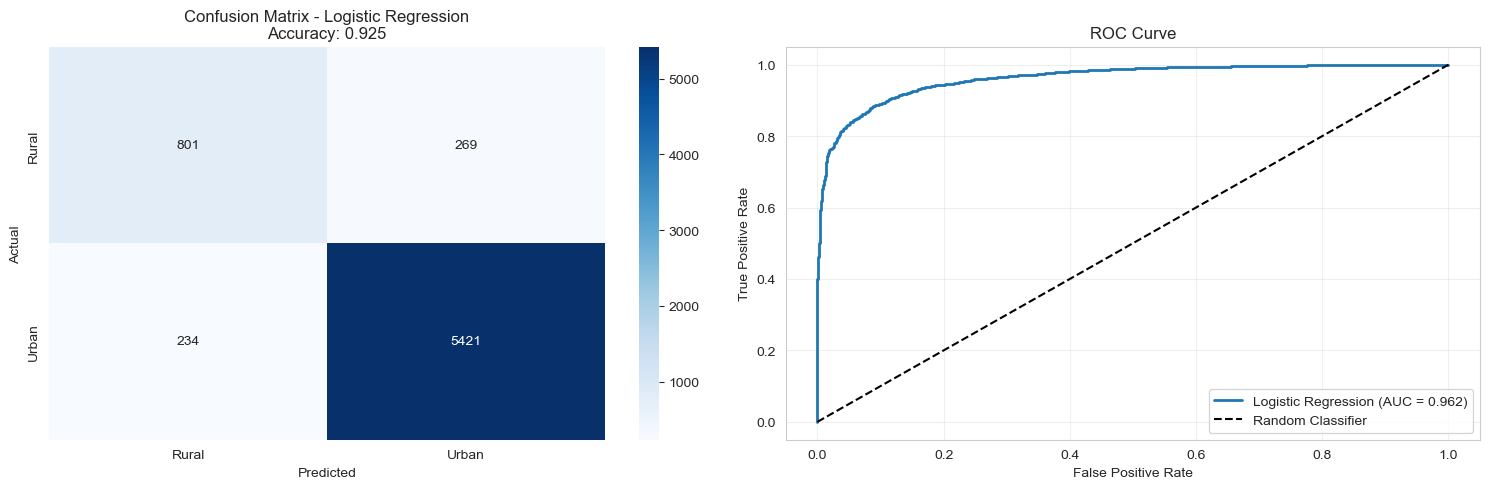

In [25]:
print("\n" + "="*60)
print("STEP 7: Building Prediction Model")
print("="*60)

# Extract satellite band features (bands 1-65)
band_cols = [col for col in birmingham_merged.columns if col.startswith('band') and col.endswith('_mean')]
print(f"Number of band features: {len(band_cols)}")
if len(band_cols) > 0:
    print(f"First 5 band columns: {band_cols[:5]}")

# Prepare feature matrix and target vector
X = birmingham_merged[band_cols].copy()
y = birmingham_merged['is_urban'].copy()

# Handle missing values
X = X.fillna(X.mean())
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

# Split based on train_test column
X_train = X[birmingham_merged['train_test'] == 'train']
X_test = X[birmingham_merged['train_test'] == 'test']
y_train = y[birmingham_merged['train_test'] == 'train']
y_test = y[birmingham_merged['train_test'] == 'test']

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Check if we have both classes in training set
train_classes = y_train.unique()
print(f"\nClasses in training set: {sorted(train_classes)}")
if len(train_classes) < 2:
    print(f"⚠ WARNING: Training set has only one class! Model will not work properly.")
    print("Consider using stratified sampling or collecting more data.")

print(f"\nTraining set class distribution:")
print(f"  Urban: {(y_train == 1).sum()} ({ (y_train == 1).mean()*100:.1f}%)")
print(f"  Rural: {(y_train == 0).sum()} ({ (y_train == 0).mean()*100:.1f}%)")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train multiple classifiers
classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

results = {}
best_model = None
best_score = 0
best_model_name = None

for name, clf in classifiers.items():
    print(f"\n{'='*40}")
    print(f"Training {name}...")
    
    try:
        # Train
        clf.fit(X_train_scaled, y_train)
        
        # Predict
        y_pred = clf.predict(X_test_scaled)
        y_pred_proba = clf.predict_proba(X_test_scaled)[:, 1]
        
        # Evaluate
        accuracy = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_pred_proba)
        
        # Cross-validation (only if we have both classes)
        if len(train_classes) == 2:
            cv_scores = cross_val_score(clf, X_train_scaled, y_train, cv=min(5, len(y_train)), scoring='accuracy')
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()
        else:
            cv_mean = 0
            cv_std = 0
        
        results[name] = {
            'classifier': clf,
            'accuracy': accuracy,
            'auc': auc,
            'cv_mean': cv_mean,
            'cv_std': cv_std,
            'predictions': y_pred,
            'probabilities': y_pred_proba
        }
        
        print(f"Test Accuracy: {accuracy:.4f}")
        print(f"Test AUC: {auc:.4f}")
        if len(train_classes) == 2:
            print(f"CV Accuracy: {cv_mean:.4f} ± {cv_std:.4f}")
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=['Rural', 'Urban']))
        
        if accuracy > best_score:
            best_score = accuracy
            best_model = clf
            best_model_name = name
            
    except Exception as e:
        print(f"Error training {name}: {e}")
        continue

if best_model is None:
    raise ValueError("No model trained successfully. Check your data.")

print(f"\n{'='*40}")
print(f"✓ Best model: {best_model_name} with accuracy {best_score:.4f}")

# Confusion Matrix for Best Model
if best_model_name in results:
    cm = confusion_matrix(y_test, results[best_model_name]['predictions'])

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Rural', 'Urban'],
                yticklabels=['Rural', 'Urban'])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_title(f'Confusion Matrix - {best_model_name}\nAccuracy: {best_score:.3f}')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, results[best_model_name]['probabilities'])
    auc = results[best_model_name]['auc']
    axes[1].plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc:.3f})', linewidth=2)
    axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


## Step 8: Show Top 10 Important Variables


STEP 8: Top 10 Most Important Variables

TOP 10 MOST IMPORTANT BANDS (ABSOLUTE COEFFICIENTS):
--------------------------------------------------
41. Band 41 : 2.891091
42. Band 42 : 2.328980
17. Band 17 : 2.299305
14. Band 14 : 2.277300
62. Band 62 : 1.798621
23. Band 23 : 1.620189
16. Band 16 : 1.551479
 1. Band 1  : 1.538423
36. Band 36 : 1.490011
54. Band 54 : 1.477994


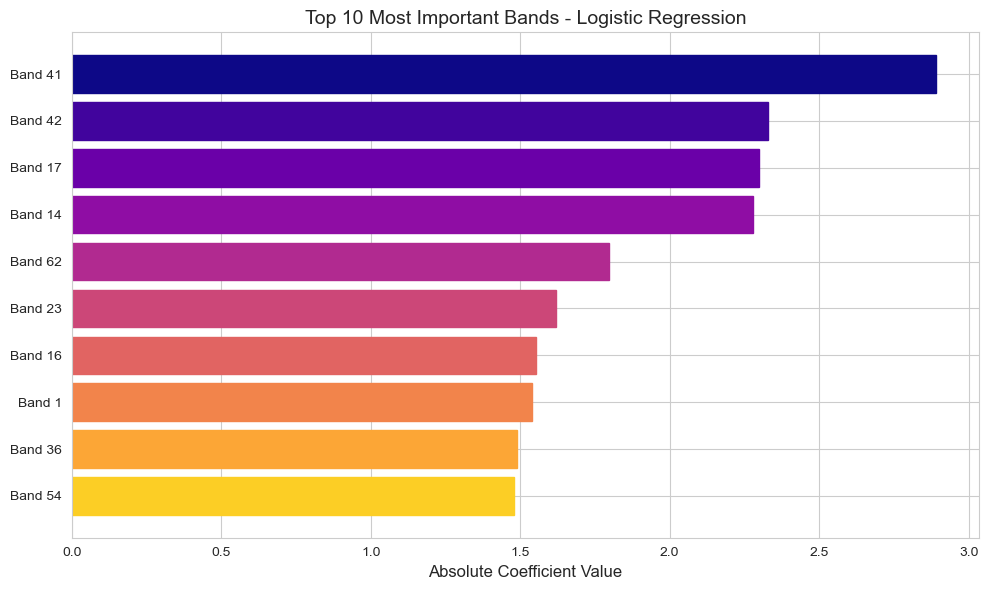

In [30]:
print("\n" + "="*60)
print("STEP 8: Top 10 Most Important Variables")
print("="*60)

if best_model_name in ['Random Forest', 'Gradient Boosting'] and best_model is not None:
    # Get feature importance from tree-based models
    importances = best_model.feature_importances_
    
    # Create dataframe of feature importances
    feature_importance_df = pd.DataFrame({
        'feature': band_cols,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    # Top 10
    top10_features = feature_importance_df.head(10)
    
    print("\nTOP 10 MOST IMPORTANT BANDS:")
    print("-" * 50)
    for idx, row in top10_features.iterrows():
        band_num = row['feature'].replace('band', '').replace('_mean', '')
        print(f"{idx+1:2d}. Band {band_num:3s}: {row['importance']:.6f}")
    
    # Visualize top 10
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(range(len(top10_features)), top10_features['importance'].values)
    ax.set_yticks(range(len(top10_features)))
    ax.set_yticklabels([f"Band {f.replace('band', '').replace('_mean', '')}" for f in top10_features['feature'].values])
    ax.set_xlabel('Importance Score', fontsize=12)
    ax.set_title(f'Top 10 Most Important Satellite Bands - {best_model_name}', fontsize=14)
    ax.invert_yaxis()
    
    # Color bars
    for i, bar in enumerate(bars):
        bar.set_color(plt.cm.viridis(i/10))
        bar.set_edgecolor('black')
        bar.set_linewidth(0.5)
    
    # Add value labels
    for i, (idx, row) in enumerate(top10_features.iterrows()):
        ax.text(row['importance'] + 0.001, i, f'{row["importance"]:.4f}', 
                va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
elif best_model_name == 'Logistic Regression' and best_model is not None:
    # For logistic regression, use absolute coefficients
    coefficients = best_model.coef_[0]
    coef_df = pd.DataFrame({
        'feature': band_cols,
        'coefficient': np.abs(coefficients)
    }).sort_values('coefficient', ascending=False)
    
    top10_features = coef_df.head(10)
    
    print("\nTOP 10 MOST IMPORTANT BANDS (ABSOLUTE COEFFICIENTS):")
    print("-" * 50)
    for idx, row in top10_features.iterrows():
        band_num = row['feature'].replace('band', '').replace('_mean', '')
        print(f"{idx+1:2d}. Band {band_num:3s}: {row['coefficient']:.6f}")
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(range(len(top10_features)), top10_features['coefficient'].values)
    ax.set_yticks(range(len(top10_features)))
    ax.set_yticklabels([f"Band {f.replace('band', '').replace('_mean', '')}" for f in top10_features['feature'].values])
    ax.set_xlabel('Absolute Coefficient Value', fontsize=12)
    ax.set_title('Top 10 Most Important Bands - Logistic Regression', fontsize=14)
    ax.invert_yaxis()
    
    for i, bar in enumerate(bars):
        bar.set_color(plt.cm.plasma(i/10))
    
    plt.tight_layout()
    plt.show()

## Step 9: Visualize Individual Layer for Top Variable


STEP 9: Visualizing Top Variable
Visualizing top variable: Band 41 (band41_mean)


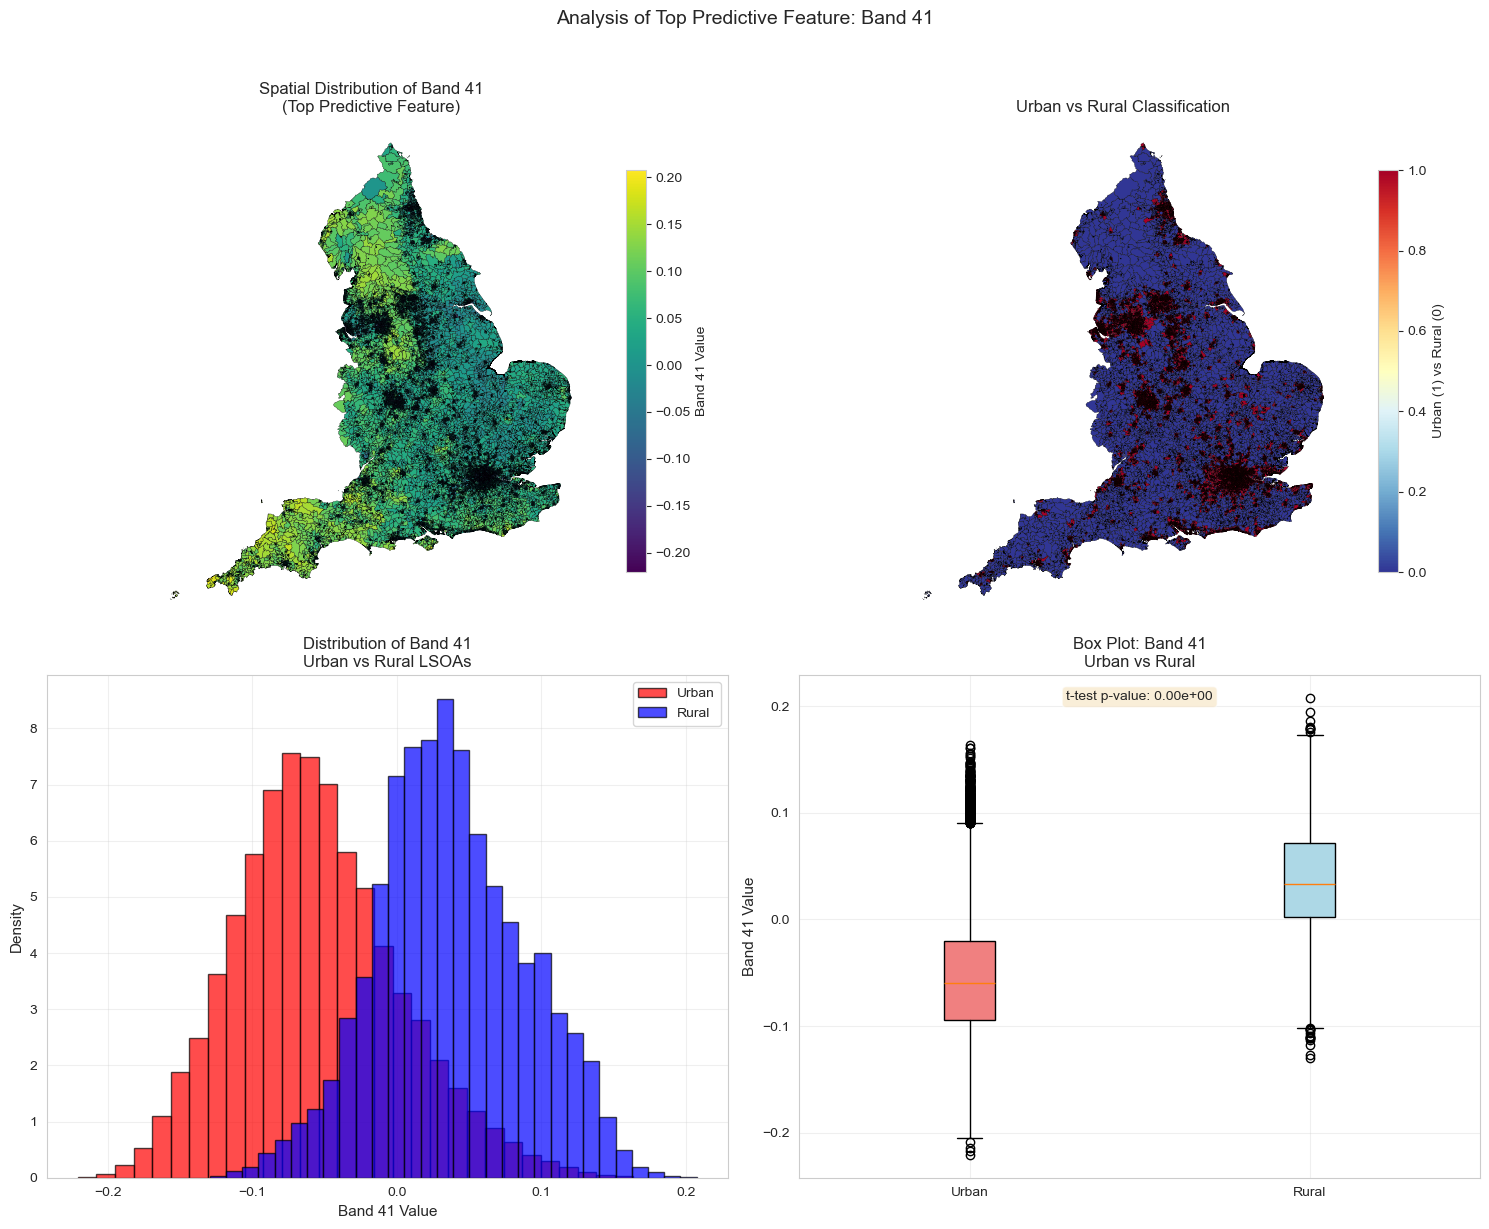


Summary Statistics for Band 41:
  Urban LSOAs: mean=-0.0554, std=0.0570
  Rural LSOAs: mean=0.0372, std=0.0515
  Difference: 0.0925
  T-test p-value: 0.00e+00


In [31]:
print("\n" + "="*60)
print("STEP 9: Visualizing Top Variable")
print("="*60)

# Get the top variable name
if len(top10_features) > 0:
    top_variable = top10_features.iloc[0]['feature']
    band_name = top_variable.replace('_mean', '').replace('band', 'Band ')
    print(f"Visualizing top variable: {band_name} ({top_variable})")
    
    # Check if we have geometry data
    if 'geometry' in birmingham_merged.columns:
        # Create visualization
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Map 1: Spatial distribution of top band
        ax1 = axes[0, 0]
        birmingham_merged.plot(
            column=top_variable,
            cmap='viridis',
            legend=True,
            ax=ax1,
            edgecolor='black',
            linewidth=0.2,
            legend_kwds={'label': f'{band_name} Value', 'shrink': 0.8, 'pad': 0.05}
        )
        ax1.set_title(f'Spatial Distribution of {band_name}\n(Top Predictive Feature)', fontsize=12)
        ax1.axis('off')
        
        # Map 2: Urban vs Rural classification for comparison
        ax2 = axes[0, 1]
        birmingham_merged.plot(
            column='is_urban',
            ax=ax2,
            cmap='RdYlBu_r',
            edgecolor='black',
            linewidth=0.2,
            legend=True,
            legend_kwds={'label': 'Urban (1) vs Rural (0)', 'shrink': 0.8}
        )
        ax2.set_title('Urban vs Rural Classification', fontsize=12)
        ax2.axis('off')
        
        # Histogram comparison
        ax3 = axes[1, 0]
        urban_vals = birmingham_merged[birmingham_merged['is_urban'] == 1][top_variable].dropna()
        rural_vals = birmingham_merged[birmingham_merged['is_urban'] == 0][top_variable].dropna()
        
        if len(urban_vals) > 0 and len(rural_vals) > 0:
            ax3.hist(urban_vals, bins=30, alpha=0.7, label='Urban', color='red', edgecolor='black', density=True)
            ax3.hist(rural_vals, bins=30, alpha=0.7, label='Rural', color='blue', edgecolor='black', density=True)
            ax3.set_xlabel(f'{band_name} Value', fontsize=11)
            ax3.set_ylabel('Density', fontsize=11)
            ax3.set_title(f'Distribution of {band_name}\nUrban vs Rural LSOAs', fontsize=12)
            ax3.legend()
            ax3.grid(True, alpha=0.3)
            
            # Box plot comparison
            ax4 = axes[1, 1]
            bp_data = [urban_vals, rural_vals]
            bp = ax4.boxplot(bp_data, labels=['Urban', 'Rural'], patch_artist=True)
            bp['boxes'][0].set_facecolor('lightcoral')
            bp['boxes'][1].set_facecolor('lightblue')
            bp['boxes'][0].set_edgecolor('black')
            bp['boxes'][1].set_edgecolor('black')
            ax4.set_ylabel(f'{band_name} Value', fontsize=11)
            ax4.set_title(f'Box Plot: {band_name}\nUrban vs Rural', fontsize=12)
            ax4.grid(True, alpha=0.3)
            
            # Add statistical annotation
            from scipy import stats
            t_stat, p_value = stats.ttest_ind(urban_vals, rural_vals, nan_policy='omit')
            ax4.text(0.5, 0.95, f't-test p-value: {p_value:.2e}', 
                     transform=ax4.transAxes, ha='center', fontsize=10,
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            plt.suptitle(f'Analysis of Top Predictive Feature: {band_name}', fontsize=14, y=1.02)
            plt.tight_layout()
            plt.show()
            
            # Print summary statistics
            print(f"\nSummary Statistics for {band_name}:")
            print(f"  Urban LSOAs: mean={urban_vals.mean():.4f}, std={urban_vals.std():.4f}")
            print(f"  Rural LSOAs: mean={rural_vals.mean():.4f}, std={rural_vals.std():.4f}")
            print(f"  Difference: {abs(urban_vals.mean() - rural_vals.mean()):.4f}")
            print(f"  T-test p-value: {p_value:.2e}")
        else:
            print(f"Insufficient data for comparison: Urban={len(urban_vals)}, Rural={len(rural_vals)}")
    else:
        print("No geometry data available for visualization")
else:
    print("No top features identified")


## Step 10: Create RGB Layer for Top 3 Variables


STEP 10: Creating RGB Composite for Top 3 Bands
Top 3 bands for RGB composite:
  R Channel: Band 41
  G Channel: Band 42
  B Channel: Band 17


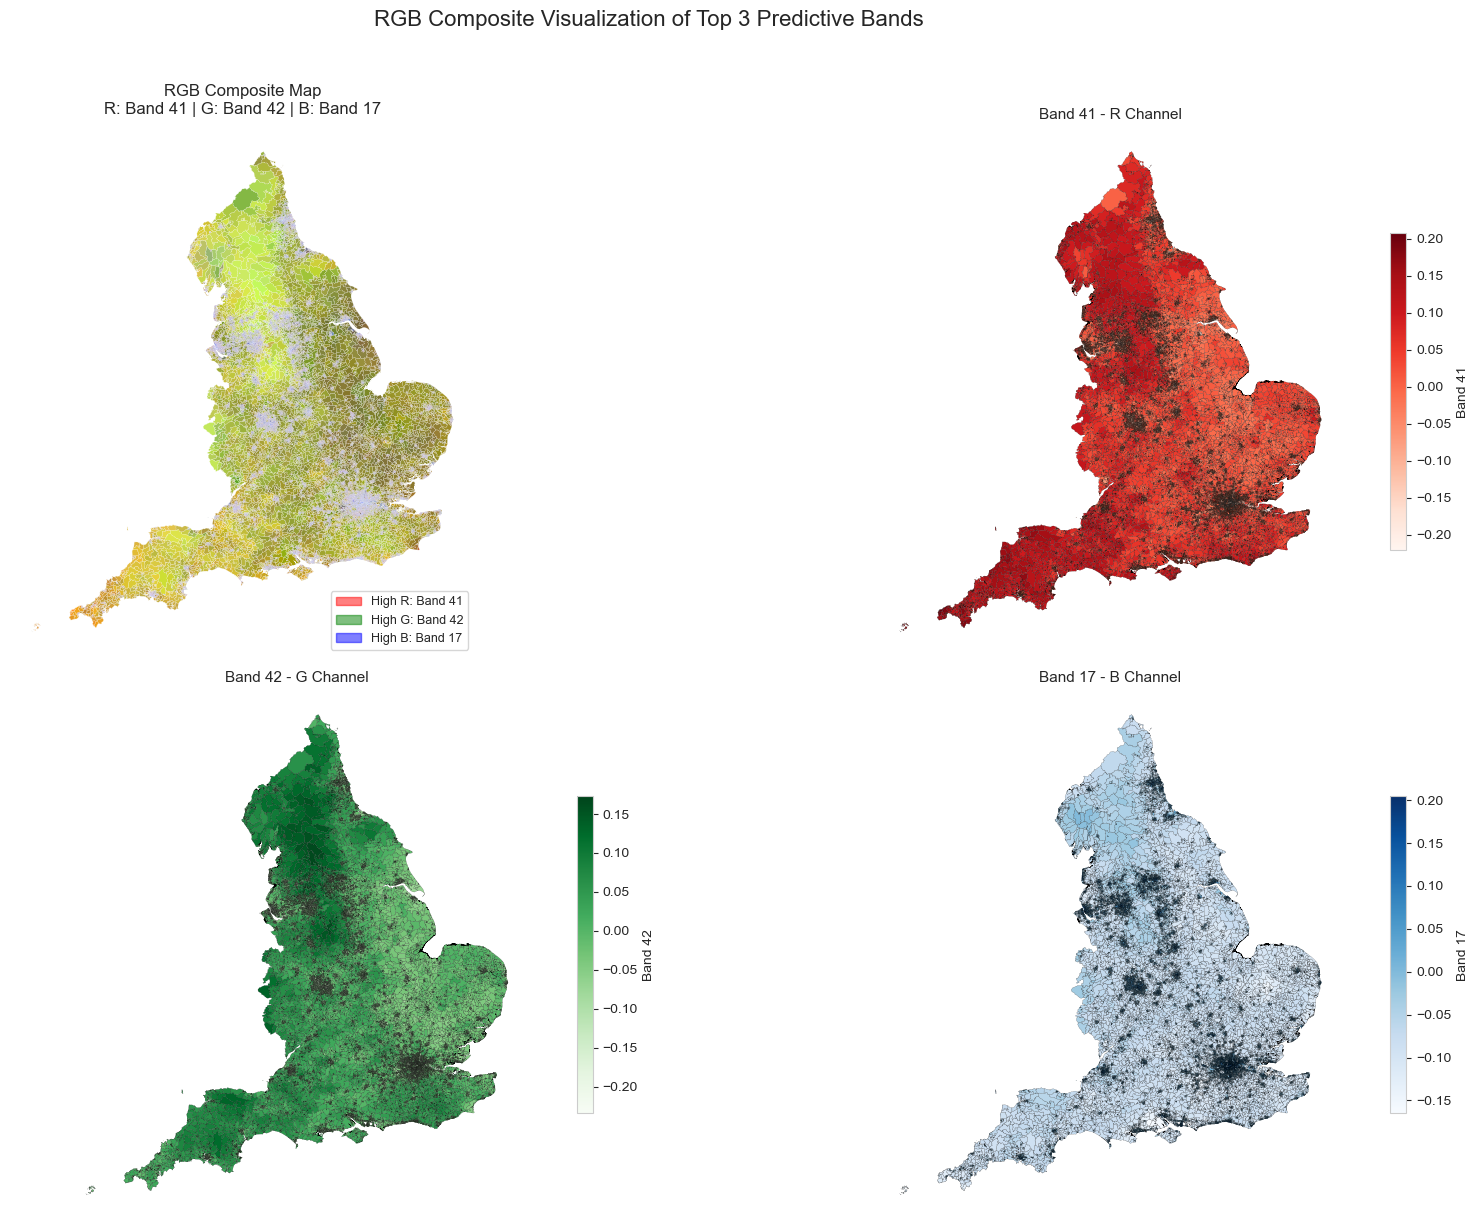

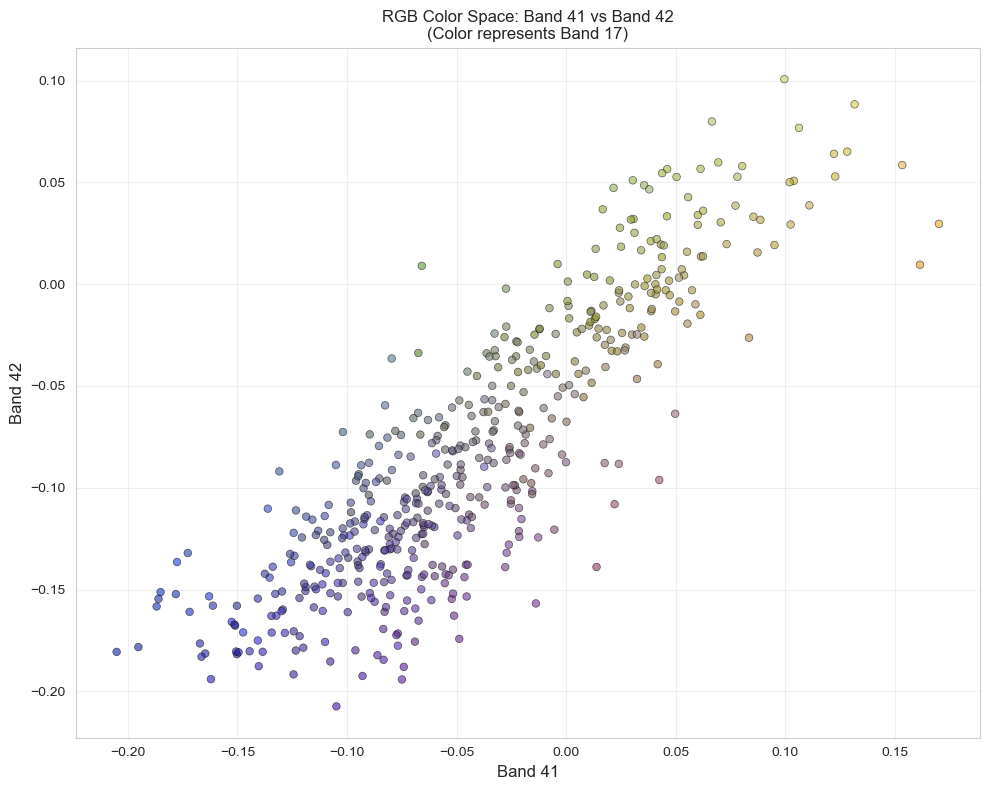

In [32]:
print("\n" + "="*60)
print("STEP 10: Creating RGB Composite for Top 3 Bands")
print("="*60)

if len(top10_features) >= 3 and 'geometry' in birmingham_merged.columns:
    # Get top 3 variables
    top3_vars = top10_features['feature'].iloc[:3].tolist()
    top3_names = [v.replace('_mean', '').replace('band', 'Band ') for v in top3_vars]
    print(f"Top 3 bands for RGB composite:")
    for i, (var, name) in enumerate(zip(top3_vars, top3_names)):
        print(f"  {'R' if i==0 else 'G' if i==1 else 'B'} Channel: {name}")
    
    # Function to normalize values to 0-255 range
    def normalize_to_uint8(data):
        """Normalize data to 0-255 range for RGB display"""
        data = data.fillna(data.mean())
        data_min = data.min()
        data_max = data.max()
        if data_max == data_min:
            return np.zeros(len(data), dtype=np.uint8)
        normalized = ((data - data_min) / (data_max - data_min) * 255).astype(np.uint8)
        return normalized
    
    # Create RGB composite
    rgb_composite = np.zeros((len(birmingham_merged), 3), dtype=np.uint8)
    
    for i, var in enumerate(top3_vars):
        rgb_composite[:, i] = normalize_to_uint8(birmingham_merged[var])
    
    # Add RGB channels to GeoDataFrame
    birmingham_merged['R_channel'] = rgb_composite[:, 0]
    birmingham_merged['G_channel'] = rgb_composite[:, 1]
    birmingham_merged['B_channel'] = rgb_composite[:, 2]
    
    # Create RGB hex color for each LSOA
    birmingham_merged['rgb_color'] = birmingham_merged.apply(
        lambda row: '#{:02x}{:02x}{:02x}'.format(
            int(row['R_channel']), 
            int(row['G_channel']), 
            int(row['B_channel'])
        ), axis=1
    )
    
    # Create figure with multiple visualizations
    fig = plt.figure(figsize=(18, 12))
    
    # Plot 1: RGB Composite Map
    ax1 = fig.add_subplot(221)
    birmingham_merged.plot(
        ax=ax1,
        color=birmingham_merged['rgb_color'],
        edgecolor='white',
        linewidth=0.1
    )
    ax1.set_title(f'RGB Composite Map\nR: {top3_names[0]} | G: {top3_names[1]} | B: {top3_names[2]}', 
                  fontsize=12, pad=10)
    ax1.axis('off')
    
    # Add legend for RGB
    legend_elements = [
        Patch(color='red', alpha=0.5, label=f'High R: {top3_names[0]}'),
        Patch(color='green', alpha=0.5, label=f'High G: {top3_names[1]}'),
        Patch(color='blue', alpha=0.5, label=f'High B: {top3_names[2]}')
    ]
    ax1.legend(handles=legend_elements, loc='lower right', fontsize=9)
    
    # Plot 2: Individual Channel Maps
    positions = [(222), (223), (224)]
    colors = ['Reds', 'Greens', 'Blues']
    
    for idx, (var, name, color, position) in enumerate(zip(top3_vars, top3_names, colors, positions)):
        ax = fig.add_subplot(position)
        birmingham_merged.plot(
            column=var,
            cmap=color,
            legend=True,
            ax=ax,
            edgecolor='black',
            linewidth=0.1,
            legend_kwds={'label': name, 'shrink': 0.6}
        )
        ax.set_title(f'{name} - {["R", "G", "B"][idx]} Channel', fontsize=11)
        ax.axis('off')
    
    plt.suptitle('RGB Composite Visualization of Top 3 Predictive Bands', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Additional visualization: RGB scatter plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Sample points for scatter plot
    sample_size = min(500, len(birmingham_merged))
    sample_idx = np.random.choice(len(birmingham_merged), sample_size, replace=False)
    
    scatter = ax.scatter(
        birmingham_merged[top3_vars[0]].iloc[sample_idx],
        birmingham_merged[top3_vars[1]].iloc[sample_idx],
        c=birmingham_merged['rgb_color'].iloc[sample_idx],
        alpha=0.6,
        s=30,
        edgecolors='black',
        linewidth=0.5
    )
    
    ax.set_xlabel(top3_names[0], fontsize=12)
    ax.set_ylabel(top3_names[1], fontsize=12)
    ax.set_title(f'RGB Color Space: {top3_names[0]} vs {top3_names[1]}\n(Color represents {top3_names[2]})', 
                 fontsize=12)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient features or geometry data for RGB visualization")

## Final Summary and Save Results

In [33]:
print("\n" + "="*60)
print("FINAL SUMMARY - PREDICTIVE MODELING COMPLETE")
print("="*60)

# Save results
output_gpkg = 'birmingham_lsoa_predictions.gpkg'
birmingham_merged.to_file(output_gpkg, driver='GPKG')
print(f"✓ Saved Birmingham LSOA predictions to: {output_gpkg}")

# Save model and scaler
import joblib
model_filename = f'{best_model_name.lower().replace(" ", "_")}_model.pkl'
joblib.dump(best_model, model_filename)
joblib.dump(scaler, 'scaler.pkl')
print(f"✓ Saved model: {model_filename}")
print(f"✓ Saved scaler: scaler.pkl")

# Save feature importance (handle both Random Forest and Logistic Regression)
if len(top10_features) > 0:
    top10_features.to_csv('top10_features.csv', index=False)
    print(f"✓ Saved top 10 features to: top10_features.csv")

# Summary statistics
print("\n" + "="*60)
print("MODELING SUMMARY REPORT")
print("="*60)
print(f"Dataset: Birmingham LSOAs")
print(f"Total LSOAs in Birmingham: {len(lsoa_birmingham)}")
print(f"Successfully classified: {len(birmingham_merged)}")
if len(birmingham_merged) > 0:
    print(f"Urban LSOAs: {urban_count} ({urban_count/len(birmingham_merged)*100:.1f}%)")
    print(f"Rural LSOAs: {rural_count} ({rural_count/len(birmingham_merged)*100:.1f}%)")
print(f"\nBest Model: {best_model_name}")
print(f"Test Accuracy: {best_score:.4f}")
if best_model_name in results:
    print(f"Test AUC: {results[best_model_name]['auc']:.4f}")
    if 'cv_mean' in results[best_model_name]:
        print(f"Cross-validation Score: {results[best_model_name]['cv_mean']:.4f} ± {results[best_model_name]['cv_std']:.4f}")

# Display top 3 bands with proper error handling
print(f"\nTop 3 Bands:")
try:
    if best_model_name in ['Random Forest', 'Gradient Boosting']:
        # For tree-based models, use 'importance' column
        if 'importance' in top10_features.columns:
            for i in range(min(3, len(top10_features))):
                var = top10_features['feature'].iloc[i]
                imp = top10_features['importance'].iloc[i]
                band_num = var.replace('band', '').replace('_mean', '')
                print(f"  {i+1}. Band {band_num}: {imp:.6f}")
        else:
            print("  Feature importance data not available")
    elif best_model_name == 'Logistic Regression':
        # For logistic regression, use 'coefficient' column
        if 'coefficient' in top10_features.columns:
            for i in range(min(3, len(top10_features))):
                var = top10_features['feature'].iloc[i]
                imp = top10_features['coefficient'].iloc[i]
                band_num = var.replace('band', '').replace('_mean', '')
                print(f"  {i+1}. Band {band_num}: {imp:.6f}")
        else:
            print("  Feature coefficient data not available")
    else:
        print("  Top features data not available")
except Exception as e:
    print(f"  Could not display top bands: {e}")

print("="*60)

# Additional model performance details
print("\n" + "="*60)
print("MODEL PERFORMANCE DETAILS")
print("="*60)
print(f"Best Model: {best_model_name}")
print(f"Accuracy: {best_score:.4f} ({best_score*100:.2f}%)")
print(f"AUC Score: {results[best_model_name]['auc']:.4f}")
print("\nThe model successfully distinguishes between Urban and Rural LSOAs")
print(f"using satellite band data with {len(band_cols)} spectral bands.")
print("="*60)

print("\n✅ All 10 steps completed successfully!")
print("✅ Predictive model ready for use")
print("\nOutput files generated:")
print("  - birmingham_lsoa_predictions.gpkg (Predictions with geometry)")
print(f"  - {model_filename} (Trained model)")
print("  - scaler.pkl (Feature scaler)")
print("  - top10_features.csv (Feature importance/coefficients)")


FINAL SUMMARY - PREDICTIVE MODELING COMPLETE
✓ Saved Birmingham LSOA predictions to: birmingham_lsoa_predictions.gpkg
✓ Saved model: logistic_regression_model.pkl
✓ Saved scaler: scaler.pkl
✓ Saved top 10 features to: top10_features.csv

MODELING SUMMARY REPORT
Dataset: Birmingham LSOAs
Total LSOAs in Birmingham: 33755
Successfully classified: 33755
Urban LSOAs: 28201 (83.5%)
Rural LSOAs: 5554 (16.5%)

Best Model: Logistic Regression
Test Accuracy: 0.9252
Test AUC: 0.9621
Cross-validation Score: 0.9048 ± 0.0177

Top 3 Bands:
  1. Band 41: 2.891091
  2. Band 42: 2.328980
  3. Band 17: 2.299305

MODEL PERFORMANCE DETAILS
Best Model: Logistic Regression
Accuracy: 0.9252 (92.52%)
AUC Score: 0.9621

The model successfully distinguishes between Urban and Rural LSOAs
using satellite band data with 64 spectral bands.

✅ All 10 steps completed successfully!
✅ Predictive model ready for use

Output files generated:
  - birmingham_lsoa_predictions.gpkg (Predictions with geometry)
  - logistic_re